In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential, Model
from keras.layers import Dense,Dropout,BatchNormalization, Input, LeakyReLU
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.metrics import AUC
from keras.regularizers import l2
import keras_tuner as kt
from imblearn.over_sampling import SMOTE
from scipy.stats import rankdata
import warnings
warnings.simplefilter('ignore')

In [83]:
# import shutil
# shutil.rmtree('/content/keras_tuner_dir')

In [84]:
train = pd.read_csv("train.csv", index_col='id')
test = pd.read_csv("test.csv", index_col='id')
train_extra=pd.read_csv("Rainfall.csv")

In [85]:
train_extra.columns = train_extra.columns.str.replace(' ', '')
train_extra = train_extra[train_extra.columns].copy()
train_extra['rainfall'] = train_extra['rainfall'].map({'no': 0, 'yes': 1})
train_extra['humidity']=train_extra['humidity'].astype(float)
train_extra['cloud']=train_extra['cloud'].astype(float)
train_features=list(train)
train_extra=train_extra[train_features]

train = pd.concat([train, train_extra], axis=0, ignore_index=True)
train = train.drop_duplicates()
train.shape

(2556, 12)

In [86]:
test['winddirection']=test['winddirection'].fillna(value=test['winddirection'].mean())
train['winddirection']=train['winddirection'].fillna(value=train['winddirection'].mean())
train['windspeed']=train['windspeed'].fillna(value=train['windspeed'].mean())

## Preprocessing

In [87]:
def generate_features(df):

    ## lag feature
    for lag in [1, 3, 7]:
        df[f'Pressure_lag{lag}'] = df['pressure'].shift(lag)
        df[f'Humidity_lag{lag}'] = df['humidity'].shift(lag)

    ## amount of change
    df['Pressure_change_1d'] = df['pressure'] - df['pressure'].shift(1)
    df['Humidity_change_1d'] = df['humidity'] - df['humidity'].shift(1)

    ## temperature related
    df['Temp_range'] = df['maxtemp'] - df['mintemp']
    df["avg_temp"] = (df["maxtemp"] + df["mintemp"]) / 2
    df['Dewpoint_diff'] = df['temparature'] - df['dewpoint']

    ## sunshine, cloud amount
    df['Sunshine_per_hour'] = df['sunshine'] / 24
    df['Cloud_per_hour'] = df['cloud'] / 24
    df['Cloud_Humidity_ratio'] = df['cloud'] / (df['humidity'] + 1e-5)
    df['Cloud_Sunshine_ratio'] = df['cloud'] / (df['sunshine'] + 1e-5)

    ## wind related
    df['Wind_x'] = df['windspeed'] * np.cos(np.radians(df['winddirection']))
    df['Wind_y'] = df['windspeed'] * np.sin(np.radians(df['winddirection']))

    ## others
    df['humidity_cloud_interaction'] = df['humidity'] * df['cloud']
    df['humidity_sunshine_interaction'] = df['humidity'] * df['sunshine']
    df['Pressure_Humidity_Interaction'] = df['pressure'] * df['humidity']
    df["cloud_wind_interaction"] = df["cloud"] * df["windspeed"]
    df['relative_dryness'] = 100 - df['humidity']
    df['sunshine_percentage'] = df['sunshine'] / (df['sunshine'] + df['cloud'] + 1e-5)
    df['cloud_percentage'] = df['cloud'] / (df['sunshine'] + df['cloud'] + 1e-5)
    df['weather_index'] = (0.4 * df['humidity']) + (0.3 * df['cloud']) - (0.3 * df['sunshine'])
    df['Temp_Ratio'] = df['temparature'] / df['maxtemp'].max()

    # df['humidity_index'] = df['dewpoint'] / df['maxtemp']
    # df['High_Cloud_Cover'] = (df['cloud'] > 60).astype(int)
    # df['High_Humidity'] = (df['humidity'] > 75).astype(int)

    # df['cloud_plus_humidity'] = df['cloud'] + df['humidity']
    # df['humidity_plus_sunshine'] = df['humidity'] + df['sunshine']
    # df['Pressure_plus_Humidity'] = df['pressure'] + df['humidity']
    # df['sunshine_under_4'] = df['sunshine'].apply(lambda x: 1 if x <= 4.0 else 0)

    df['Try'] = (df['humidity'] + df['cloud'] + df['dewpoint'])
    df['Try_2'] = (df['cloud'] - df['sunshine']) + df['temparature']

    # wet-bulb temperature
    def calc_wet_bulb(T, RH):
        return T * np.arctan(0.151977 * np.sqrt(RH + 8.313659)) + \
               np.arctan(T + RH) - np.arctan(RH - 1.676331) + \
               0.00391838 * RH**(3/2) * np.arctan(0.023101 * RH) - 4.686035

    df['wet_bulb_temp'] = calc_wet_bulb(df['temparature'], df['humidity'])

    # saturated vapor pressure
    def calc_saturation_vapor_pressure(temp):
        return 6.11 * np.exp((17.27 * temp) / (temp + 237.3))

    df['e_s_temp'] = calc_saturation_vapor_pressure(df['temparature'])
    df['e_s_dewpoint'] = calc_saturation_vapor_pressure(df['dewpoint'])

    # vapor pressure deficit
    df['vapor_pressure_deficit'] = df['e_s_temp'] - df['e_s_dewpoint']

    df.fillna(method='bfill', inplace=True)

    return df

In [88]:
imputer = KNNImputer(n_neighbors=5)
test["winddirection"] = imputer.fit_transform(test[["winddirection"]])

train_df = generate_features(train)
test_df = generate_features(test)

x = train_df.drop('rainfall',axis=1)
y = train_df["rainfall"]

sc = StandardScaler().fit(x.values)
x = pd.DataFrame(sc.transform(x), index=x.index, columns=x.columns)
test_df = pd.DataFrame(sc.transform(test_df), index=test_df.index, columns=test_df.columns)

X_temp, X_test, y_temp, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1, random_state=42)

In [89]:
X_train.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,...,sunshine_percentage,cloud_percentage,weather_index,Temp_Ratio,Try,Try_2,wet_bulb_temp,e_s_temp,e_s_dewpoint,vapor_pressure_deficit
1931,-0.437015,-0.541310,0.606891,0.184875,0.208133,0.465570,-0.094115,0.371406,-0.391799,-0.428662,...,-0.423531,0.423531,0.247436,0.184875,0.344359,0.446617,0.162750,0.059316,0.403207,-0.710264
576,0.491160,-0.870715,0.975321,0.904376,0.811494,1.021565,0.516749,0.692700,-0.718054,1.566062,...,-0.607435,0.607435,0.714266,0.904376,0.899932,0.971861,1.012947,0.938862,1.167904,0.006759
351,1.728728,0.932345,-0.796652,-1.064784,-1.232146,-1.332147,0.883268,0.692700,-0.989933,-0.802673,...,-0.744725,0.744725,0.882594,-1.064784,0.514999,0.523016,-0.882362,-1.108184,-1.372322,-0.021382
377,-1.267953,1.851212,-1.568601,-1.954693,-2.010676,-2.184673,-1.193672,1.335287,-1.044309,-1.176684,...,-0.772558,0.772558,0.530227,-1.954693,0.134035,0.881137,-2.130749,-1.717402,-1.929450,-0.458783
488,-0.286739,-0.055871,0.027929,0.184875,0.363839,0.150506,1.494133,0.692700,-0.772430,-0.802673,...,-0.634647,0.634647,1.080100,0.184875,1.030888,0.799963,0.504851,0.059316,0.020577,0.115220


In [90]:
# X_temp, X_test, y_temp, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

## MLP

In [91]:
# Criando um Autoencoder melhorado
def build_autoencoder(input_dim):
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(256, kernel_regularizer=l2(1e-4))(input_layer)
    encoded = LeakyReLU(alpha=0.1)(encoded)
    encoded = Dense(128, kernel_regularizer=l2(1e-4))(encoded)
    encoded = LeakyReLU(alpha=0.1)(encoded)
    encoded = Dense(64, kernel_regularizer=l2(1e-4))(encoded)
    encoded = LeakyReLU(alpha=0.1)(encoded)

    decoded = Dense(128, kernel_regularizer=l2(1e-4))(encoded)
    decoded = LeakyReLU(alpha=0.1)(decoded)
    decoded = Dense(256, kernel_regularizer=l2(1e-4))(decoded)
    decoded = LeakyReLU(alpha=0.1)(decoded)
    decoded = Dense(input_dim, activation='sigmoid')(decoded)

    autoencoder = Model(input_layer, decoded)
    encoder = Model(input_layer, encoded)

    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder

# Treinar Autoencoder
autoencoder, encoder = build_autoencoder(X_train.shape[1])
early_stopping_pretraining = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

autoencoder.fit(X_train, X_train, epochs=50, batch_size=32, validation_data=(X_val, X_val),
                callbacks=[early_stopping_pretraining], verbose=1)

# Congelar o encoder no início do treinamento
encoder.trainable = False

Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1.0448 - val_loss: 0.7591
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7777 - val_loss: 0.7151
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7318 - val_loss: 0.6832
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6945 - val_loss: 0.6637
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6981 - val_loss: 0.6476
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6547 - val_loss: 0.6374
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6784 - val_loss: 0.6324
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6515 - val_loss: 0.6291
Epoch 9/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6363 - val_loss: 0.6261
Epoch 10/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6461 - val_loss: 0.6239
Epoch 11/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6523 - val_loss: 0.6228
Epoch 12/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6179 - val_lo

In [92]:
# Criando modelo principal para o tuner
def build_model(hp):
    model = Sequential([
        encoder,  # Camadas pré-treinadas do autoencoder
        Dense(hp.Int('units_1', 128, 512, 128), kernel_regularizer=l2(1e-4)),
        LeakyReLU(alpha=0.1),
        BatchNormalization(),
        Dropout(hp.Float('dropout_1', 0.1, 0.4, 0.1)),

        Dense(hp.Int('units_2', 64, 256, 64), kernel_regularizer=l2(1e-4)),
        LeakyReLU(alpha=0.1),
        BatchNormalization(),
        Dropout(hp.Float('dropout_2', 0.1, 0.4, 0.1)),

        Dense(32, kernel_regularizer=l2(1e-4)),
        LeakyReLU(alpha=0.1),
        BatchNormalization(),
        Dense(16, kernel_regularizer=l2(1e-4)),
        LeakyReLU(alpha=0.1),
        BatchNormalization(),

        Dense(1, activation='sigmoid')
    ])

    optimizer = Adam(hp.Choice('learning_rate', [0.01, 0.001, 0.0001]))
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Criando tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=2,
    directory='keras_tuner_dir',
    project_name='mlp_tuning'
)

# Early stopping para o tuner
early_stopping_tuner = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Iniciar busca pelos melhores hiperparâmetros
tuner.search(X_train, y_train, epochs=100, validation_data=(X_val, y_val), callbacks=[early_stopping_tuner])

# Melhor conjunto de hiperparâmetros encontrados
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Melhores hiperparâmetros:", best_hps.values)

Trial 10 Complete [00h 01m 33s]
val_accuracy: 0.8975609540939331

Best val_accuracy So Far: 0.8975609540939331
Total elapsed time: 00h 12m 50s
Melhores hiperparâmetros: {'units_1': 128, 'dropout_1': 0.2, 'units_2': 64, 'dropout_2': 0.30000000000000004, 'learning_rate': 0.001}


In [94]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = []  # Lista para armazenar os modelos treinados
auc_scores = []  # Lista para armazenar o AUC de cada modelo
histories = []  # Lista para armazenar o histórico de cada modelo

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"Treinando fold {fold+1}/5...")

    # Criar os conjuntos de treinamento e validação para este fold
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Criando um novo modelo para cada fold
    model = Sequential([
        encoder,  # Reutilizando pesos do encoder
        Dense(best_hps.get('units_1'), kernel_regularizer=l2(1e-4)),
        LeakyReLU(alpha=0.1),
        BatchNormalization(),
        Dropout(best_hps.get('dropout_1')),

        Dense(best_hps.get('units_2'), kernel_regularizer=l2(1e-4)),
        LeakyReLU(alpha=0.1),
        BatchNormalization(),
        Dropout(best_hps.get('dropout_2')),

        Dense(32, kernel_regularizer=l2(1e-4)),
        LeakyReLU(alpha=0.1),
        BatchNormalization(),

        Dense(16, kernel_regularizer=l2(1e-4)),
        LeakyReLU(alpha=0.1),
        BatchNormalization(),

        Dense(1, activation='sigmoid')  # Binary classification
    ])

    # Compilar modelo
    optimizer = Adam(learning_rate=best_hps.get('learning_rate'))
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[AUC(name='auc')])

    # Treinar modelo neste fold
    history = model.fit(
        X_train_fold, y_train_fold,
        epochs=300,
        batch_size=32,
        validation_data=(X_val_fold, y_val_fold),
        callbacks=[early_stopping_final, reduce_lr],
        verbose=1
    )

    # Salvar modelo e histórico
    models.append(model)
    histories.append(history)

    # Avaliar o modelo no conjunto de validação
    val_auc = model.evaluate(X_val_fold, y_val_fold, verbose=0)[1]
    auc_scores.append(val_auc)
    print(f"Fold {fold+1}: Val AUC = {val_auc:.4f}")

# Exibir a média do AUC nos folds
print(f"Média do AUC nos folds: {np.mean(auc_scores):.4f}")

Treinando fold 1/5...
Epoch 1/300
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - auc: 0.7865 - loss: 0.6606 - val_auc: 0.9088 - val_loss: 0.4525 - learning_rate: 0.0010
Epoch 2/300
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - auc: 0.8757 - loss: 0.4684 - val_auc: 0.9090 - val_loss: 0.4583 - learning_rate: 0.0010
Epoch 3/300
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.9042 - loss: 0.4125 - val_auc: 0.9147 - val_loss: 0.4273 - learning_rate: 0.0010
Epoch 4/300
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - auc: 0.8866 - loss: 0.4126 - val_auc: 0.9149 - val_loss: 0.4312 - learning_rate: 0.0010
Epoch 5/300
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - auc: 0.8973 - loss: 0.3864 - val_auc: 0.9194 - val_loss: 0.4001 - learning_rate: 0.0010
Epoch 6/300
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - auc: 0.9049 - loss: 0.3665 - val_auc: 0.9178 - val_loss: 0.3897 - learning_rate: 0.0010
Epoch 7/300
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.8816 - loss: 0.3850 - val_auc: 0.9222 - val_loss: 0.3826 - learning_ra

In [95]:
# Inicializar uma matriz para armazenar as previsões de cada modelo
predictions_all = np.zeros((len(X_test), len(models)))

# Gerar previsões com cada modelo treinado no K-Fold
for i, model in enumerate(models):
    predictions_all[:, i] = np.squeeze(model.predict(X_test))

# Tirar a média das previsões para obter um resultado final mais robusto
final_predictions = np.mean(predictions_all, axis=1)

# Converter previsões em classes (0 ou 1) usando um threshold de 0.5
final_predictions_class = (final_predictions >= 0.5).astype(int)

# Calcular Accuracy
test_accuracy = accuracy_score(y_test, final_predictions_class)

# Calcular AUC
test_auc = roc_auc_score(y_test, final_predictions)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test AUC: {test_auc:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
Test Accuracy: 0.8438
Test AUC: 0.8421


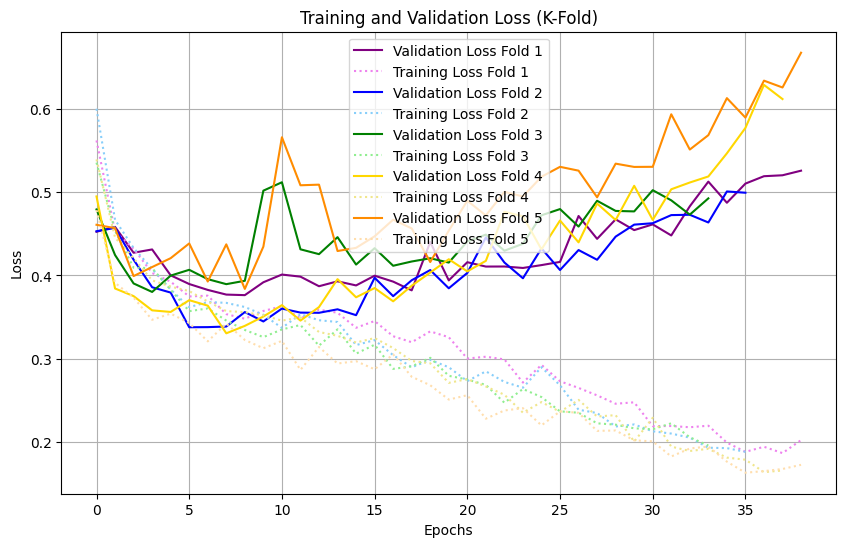

In [96]:
# Definir cores para os folds
cores_validacao = ['purple', 'blue', 'green', 'gold', 'darkorange']
cores_treinamento = ['violet', 'lightskyblue', 'lightgreen', 'khaki', 'navajowhite']

plt.figure(figsize=(10, 6))

for i, history in enumerate(histories):
    # Plot das perdas de validação (linha sólida)
    plt.plot(history.history['val_loss'], color=cores_validacao[i], label=f'Validation Loss Fold {i+1}')

    # Plot das perdas de treinamento (linha pontilhada)
    plt.plot(history.history['loss'], color=cores_treinamento[i], linestyle='dotted', label=f'Training Loss Fold {i+1}')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (K-Fold)')
plt.legend()
plt.grid()
plt.show()

## Submission CSV

In [98]:
# Escolher o melhor modelo baseado no AUC do K-Fold
best_fold_idx = np.argmax(auc_scores)  # Pega o índice do melhor modelo
print(f"Usando o modelo do Fold {best_fold_idx + 1} para testar!")

# Avaliação no conjunto de teste
test_loss, test_auc = models[best_fold_idx].evaluate(X_test, y_test)
print(f"Test Loss : {test_loss}")
print(f"Test AUC: {test_auc}")

# Fazer previsões
predictions = models[best_fold_idx].predict(test_df)
result_df = pd.DataFrame({
    "id": np.arange(2190, 2190 + len(predictions)),
    "rainfall": np.squeeze(predictions)
})

print(result_df.head())

Usando o modelo do Fold 4 para testar!
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.8322 - loss: 0.4677 
Test Loss : 0.4463202953338623
Test AUC: 0.8452816605567932
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
     id  rainfall
0  2190  0.960081
1  2191  0.960624
2  2192  0.951814
3  2193  0.077350
4  2194  0.129596


In [99]:
# Inicializar uma matriz para armazenar as previsões de cada modelo
predictions_all = np.zeros((len(test_df), len(models)))

# Gerar previsões com cada modelo treinado no K-Fold
for i, model in enumerate(models):
    predictions_all[:, i] = np.squeeze(model.predict(test_df))

# Tirar a média das previsões para obter um resultado final mais robusto
final_predictions = np.mean(predictions_all, axis=1)

# Criar DataFrame com os resultados
result_df = pd.DataFrame({
    "id": np.arange(2190, 2190 + len(final_predictions)),
    "rainfall": final_predictions
})

print(result_df.head())

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
     id  rainfall
0  2190  0.964857
1  2191  0.966305
2  2192  0.935994
3  2193  0.150629
4  2194  0.188605


In [102]:
result_df.to_csv("submission.csv", index=False)
print(f"Previsões salvas em: submission.csv")

Previsões salvas em: submission.csv


In [103]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ functional_14 (Functional)           │ (None, 64)                  │          52,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_24 (LeakyReLU)           │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_24               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_25 (LeakyReLU)           │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_25               │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_26 (LeakyReLU)           │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_26               │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_27 (LeakyReLU)           │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_27               │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 216,773 (846.77 KB)

 Trainable params: 72,097 (281.63 KB)

 Non-trainable params: 480 (1.88 KB)

 Optimizer params: 144,196 (563.27 KB)